## Performance and energy comparison on MG

In [11]:
import matplotlib.pyplot as plt
import numpy as np

NRMSE_list = np.array([])
Node_list = np.array([])
Power_list = np.array([])

# This work
NRMSE = 0.059
Nodes = 15
ReservoirW = 15.8*10**-12
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# This work (larger network)
NRMSE = 0.043
Nodes = 45
ReservoirW = 39.76*10**-12
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# Versatile and Robust Reservoir Computing with PWM-Driven Heterogenous R–C Circuits
NRMSE = 0.015
Nodes = 40
ReservoirW = (3.3)**2/(40*10**3)*(2/4) # V^2 / resistance * (avg pulse dur/pulse dur and 0 V dur)
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# A Dynamic Memory for Reservoir Computing Utilizing IonMigration in CuInP2 S6
NRMSE = 0.014 # t_delay of 30 instead of 17
Nodes = 40
ReservoirW = 3.0 * 4 * 500*10**-9 # input V x parallel reservoirs x typical current at 3V at ~10 ms inputs (Fig. 2d)
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# Rotating neurons for all-analog implementation of cyclic reservoir computing
NRMSE = 0.03
Nodes = 64
ReservoirW = 32.7*10**-6 # Explicit estimate reported in paper
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# Experimental demonstration of a skyrmion-enhanced strain-mediated physical reservoir computing system
NRMSE = 0.16
Nodes = 50 # Value of Nr
ReservoirW = 850*10**-9 # Estimate in S8 of SI
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)

# Interface-type tunable oxygen ion dynamics for physical reservoir computing
NRMSE = 0.0081
Nodes = 25*50 # Value of N x M (masks) x (length per mask)
ReservoirW = Nodes*3*200*10**-9 # Nodes x voltage pulse V x typical current
Node_list = np.append(Node_list, Nodes)
NRMSE_list = np.append(NRMSE_list, NRMSE)
Power_list = np.append(Power_list, ReservoirW)


labels = ["This work (simulated)\nSmall network","Larger network","PWM RC", "CIPS", "Rotating neurons", "Skyrmion","HZO"]

marker_cycle = ['o',  # circle
                'o',  # circle
                '*',  # star
                  's',  # square
                'D',
               '^',
               'v']  # diamond

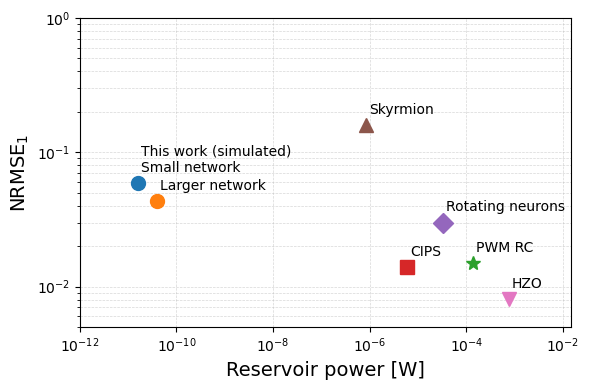

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

for xi, yi, lab, mk in zip(Power_list, NRMSE_list, labels, marker_cycle):
    # Plot the single point with its own marker
    ax.plot(xi, yi,
            marker=mk,
            markersize=10,
            linestyle='',
            label=lab)               # optional: adds a legend entry

    # Add a text label slightly offset from the point
    if lab == "CIPS":
        ax.text(xi * 1.15, yi * 1.15, lab,
                fontsize=10,
                ha='left', va='bottom')
    else:
        ax.text(xi * 1.15, yi * 1.15, lab,
                fontsize=10,
                ha='left', va='bottom')

# Switch both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')

x_min, x_max = 10**-12, 1.5*10**-2   # → 10⁻¹·⁵ to 10²·³⁰ (Matplotlib will round to nice decades)
y_min, y_max = 0.005, 1   # same idea for Y

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Optional cosmetics
ax.set_xlabel('Reservoir power [W]',fontsize=14)
ax.set_ylabel('NRMSE$_1$',fontsize=14)
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.5)

plt.tight_layout()
#plt.show()
plt.savefig("output/NRMSE_power.pdf",bbox_inches='tight')